## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolínea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué rendimiento presentan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga datos y representa la serie

In [38]:
# Code
df = pd.read_csv ('data\AirPassengers.csv')

In [ ]:
df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


Text(0.5, 1.0, 'Pasajeros')

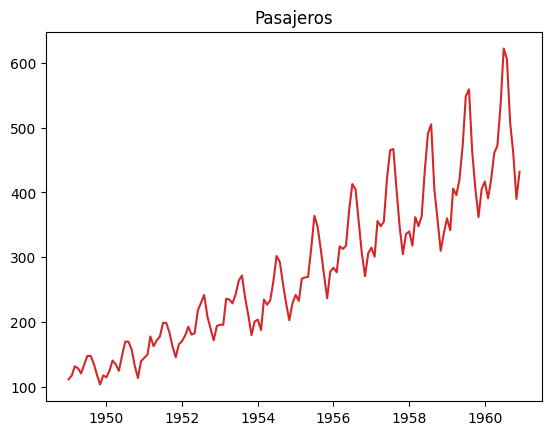

In [39]:
df['date'] = pd.to_datetime (df['date'])
plt.plot(df['date'], df['value'], color='tab:red')
plt.title ('Pasajeros')

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window comparando el valor de seasonality obtenido en el apartado anterior

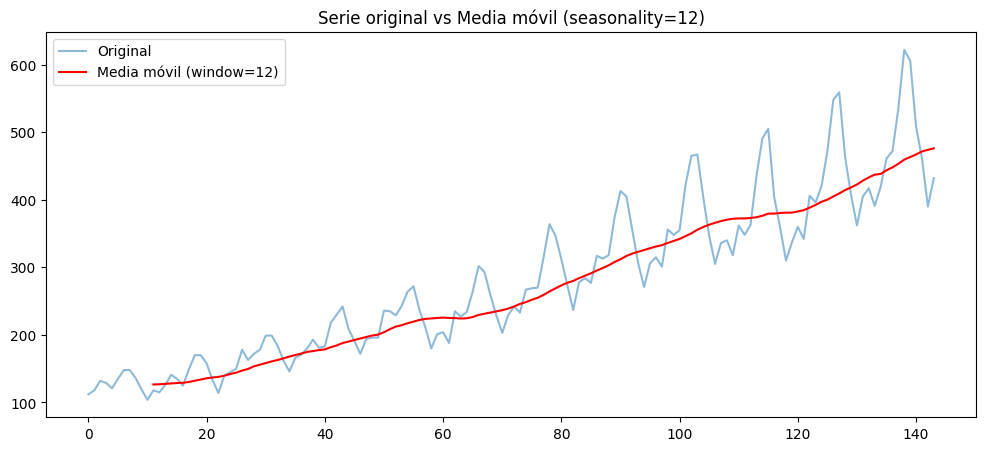

In [7]:
# Code
# Se entiende que el periodo de seasonality del anterior es 12 
period = 12
plt.figure(figsize=(12, 5))
plt.plot(df['value'], label='Original', alpha=0.5)
plt.plot(df['value'].rolling(window=period).mean(), 
         label=f'Media móvil (window={period})', 
         color='red')
plt.legend()
plt.title(f'Serie original vs Media móvil (seasonality={period})')
plt.show()

## 3. Comprueba de manera estadística si la serie es o no estacionaria.

In [8]:
# Aplicamos Dickey fuller

from statsmodels.tsa.stattools import adfuller
result = adfuller(df['value'].values)
result[1]

np.float64(0.991880243437641)

In [ ]:
# Hipótesis nula. Con un 99% de probabilidad no es una serie estacionaria

## 4. Aplica una transformación logarítmica

In [40]:
# Code
import numpy as np
df ['value'] = np.log1p (df ['value'])

## 5. Divide en train y test. Guarda 20 muestras para test.

In [41]:
# Code
# Hay que reservar siempre las últimas para test
X = df['value']

train = X[:-20]
test = X[-20:]

In [37]:
train

,date,value,t-12,t-11,t-10,t-9,t-8,t-7,t-6,t-5,t-4,t-3,t-2,t-1
12,1950-01-01,4.753590,4.727388,4.779123,4.890349,4.867534,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123
13,1950-02-01,4.844187,4.779123,4.890349,4.867534,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123,4.753590
14,1950-03-01,4.955827,4.890349,4.867534,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123,4.753590,4.844187
15,1950-04-01,4.912655,4.867534,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123,4.753590,4.844187,4.955827
16,1950-05-01,4.836282,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123,4.753590,4.844187,4.955827,4.912655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,1958-05-01,5.897154,5.874931,6.047372,6.144186,6.148468,6.003887,5.852202,5.723585,5.820083,5.831882,5.765191,5.894403,5.855072
113,1958-06-01,6.077642,6.047372,6.144186,6.148468,6.003887,5.852202,5.723585,5.820083,5.831882,5.765191,5.894403,5.855072,5.897154
114,1958-07-01,6.198479,6.144186,6.148468,6.003887,5.852202,5.723585,5.820083,5.831882,5.765191,5.894403,5.855072,5.897154,6.077642
115,1958-08-01,6.226537,6.148468,6.003887,5.852202,5.723585,5.820083,5.831882,5.765191,5.894403,5.855072,5.897154,6.077642,6.198479


## 6. Crea tu primer modelo ARIMA

In [42]:
# Code

from pmdarima.arima import ARIMA

# Pongo los parámetros un poco a ojo
model_ma = ARIMA(order = (2,1,12)) # 2 lags (AR) 1 (diferenciacion) y #12 (MA) ventana movil
model_ma.fit(train)

c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,"(2, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,False
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,None
,trend,None
,with_intercept,True


In [43]:
predictions = model_ma.predict (n_periods =len(test))

## 7. Representa en una gráfica los datos de test y tus predicciones.

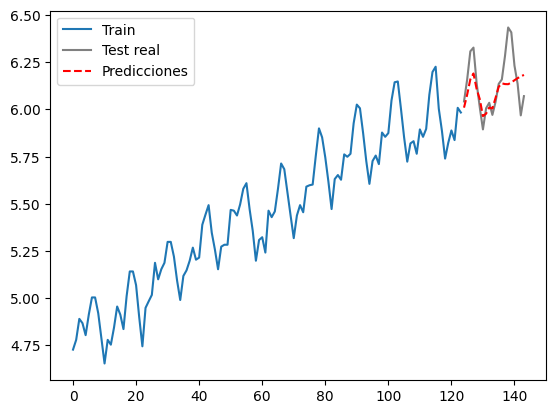

In [48]:
# Code
plt.plot(df.index[:-20], train, label = 'Train')
plt.plot(df.index[-20:], test, label = 'Test real', color='grey')
plt.plot (df.index[-20:], predictions, color='red', label='Predicciones', linestyle='--')
plt.legend()
plt.show();

In [ ]:
# Bueeeeeno.... definitivamente no es BRUTAL :-)

## 8. Prueba otros modelos supervisados, a ver qué performance presentan.

In [ ]:
# Code
from sklearn.linear_model import LinearRegression

# Hay que generar los valores pasados como featues. Con el shift, desplazo i valores la columna

for i in range(12,0,-1):
    df['t-'+str(i)] = df['value'].shift(i)

df.dropna(inplace=True) # hay Nans en las primeras 12 filas (no tienen valores previos para generar la feature)
df

,date,value,t-12,t-11,t-10,t-9,t-8,t-7,t-6,t-5,t-4,t-3,t-2,t-1
12,1950-01-01,4.753590,4.727388,4.779123,4.890349,4.867534,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123
13,1950-02-01,4.844187,4.779123,4.890349,4.867534,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123,4.753590
14,1950-03-01,4.955827,4.890349,4.867534,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123,4.753590,4.844187
15,1950-04-01,4.912655,4.867534,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123,4.753590,4.844187,4.955827
16,1950-05-01,4.836282,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123,4.753590,4.844187,4.955827,4.912655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,1960-08-01,6.408529,6.327937,6.139885,6.011267,5.894403,6.006353,6.035481,5.971262,6.040255,6.135565,6.159095,6.284134,6.434547
140,1960-09-01,6.232448,6.139885,6.011267,5.894403,6.006353,6.035481,5.971262,6.040255,6.135565,6.159095,6.284134,6.434547,6.408529
141,1960-10-01,6.135565,6.011267,5.894403,6.006353,6.035481,5.971262,6.040255,6.135565,6.159095,6.284134,6.434547,6.408529,6.232448
142,1960-11-01,5.968708,5.894403,6.006353,6.035481,5.971262,6.040255,6.135565,6.159095,6.284134,6.434547,6.408529,6.232448,6.135565


In [27]:
# 80% train y 20% test
train_size = int(len(df) * 0.8)
train = df[:train_size]
test  = df[train_size:]

X_train = train.drop(['date','value'], axis=1)
y_train = train['value']
X_test  = test.drop(['date','value'], axis=1)
y_test  = test['value']

In [28]:

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

MAE:  0.03
RMSE: 0.04


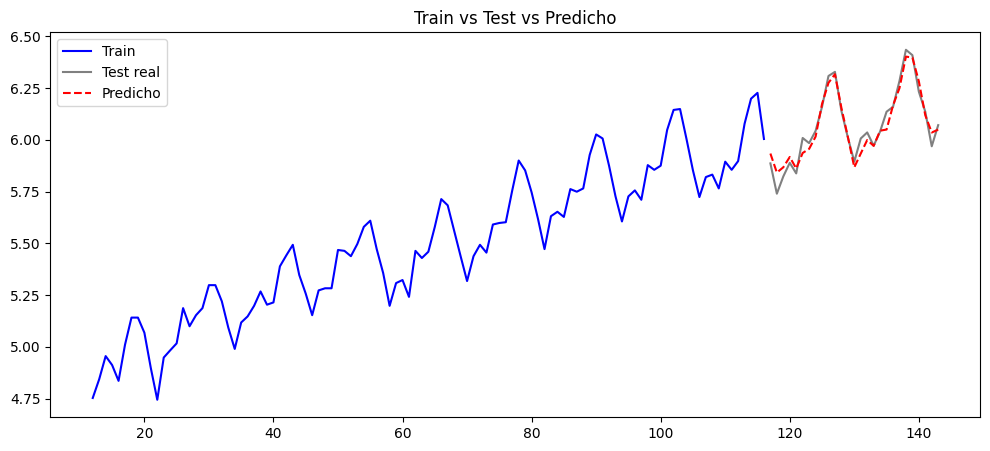

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(y_train.index, y_train, label='Train', color='blue')
plt.plot(y_test.index, y_test, label='Test real', color='grey')
plt.plot(y_test.index, y_pred, label='Preciccion', color='red', linestyle='--')

plt.legend()
plt.title('Train vs Test vs Predicho')
plt.show()